# Training: block-level urban poverty rate (2018)

Target: `Pobreza2018`, the poverty rate (%) of each urban block (*manzana*), available only for
the blocks of some large cities. Models are trained on those blocks and then used to predict the
poverty rate of urban blocks without data.

Workflow:
1. 80% / 20% train-test split **by district (UBIGEO)**.
2. Nested cross-validation on the training set to compare 9 models (linear and tree-based).
3. Final hyperparameters per model, tuned on the full training set.
4. Ensembles (simple average, weighted average, stacking) of the best models.
5. Evaluation on the **full test set** (districts never used for training or tuning).
6. Refit on all labeled blocks and prediction for blocks without data.

In [1]:
import time
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import loguniform, randint, uniform

from sklearn.model_selection import GroupShuffleSplit

# Models
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, HistGradientBoostingRegressor,
                              AdaBoostRegressor)
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")

In [2]:
# Project helper functions (scr/utils.py).
# insert(0, ...) puts scr/ first in the search path, so no other package called `utils` shadows it.
sys.path.insert(0, str(Path.cwd().parent / "scr"))

from utils import *

In [3]:
datasetTr = pd.read_stata(r"..\data\temporal_data\DataForML.dta")

In [4]:
datasetTr

,IDMANZANA,UBIGEO,POB_TOTAL,latitude,longitude,Pov2013,juntos,POB_TOTAL_district,p21_1_tPercapita,p21_2_tPercapita,...,PopManufConstOutlof_media,PopNonInsuranceOutdbscan_missfor,PopNonSpanishOutdbscan_missfores,PopServicesOutlof_knn,PopShare1529Outiforest_media,PopShare3044OutInter_missforest,PopShare4564Outiforest_knn,PopUtilitiesOutiforest_media,PopWhiteCollarOutlof_knn,light_meanOutlof_knn
0,01010100100001F,10101,34,-6.220337,-77.879663,12.27,0.0,28103,1.709055e-07,6.103769e-07,...,0.000000,0.347211,0.042416,0.300000,0.255553,0.000000,0.083162,0.003889,0.000000,7.661607
1,01010100100001K,10101,70,-6.222220,-77.878285,12.27,0.0,28103,1.709055e-07,6.103769e-07,...,0.416667,0.160000,0.000000,0.500000,0.314286,0.200000,0.071429,0.000000,0.027778,9.609583
2,01010100100001L,10101,62,-6.222649,-77.878356,12.27,0.0,28103,1.709055e-07,6.103769e-07,...,0.117647,0.052632,0.000000,0.529412,0.274194,0.112903,0.112903,0.000000,0.000000,10.067836
3,01010100100002D,10101,42,-6.223522,-77.878100,12.27,0.0,28103,1.709055e-07,6.103769e-07,...,0.400000,0.296296,0.000000,0.333333,0.261905,0.309524,0.095238,0.000000,0.266667,16.411531
4,01010100100003B,10101,70,-6.224407,-77.877591,12.27,0.0,28103,1.709055e-07,6.103769e-07,...,0.160000,0.350877,0.014286,0.720000,0.385714,0.185714,0.100000,0.000000,0.280000,16.411531
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199910,250401001000210,250401,54,-9.773107,-70.711963,23.93,0.0,912,3.600467e-05,4.800622e-06,...,0.052632,0.432432,0.296296,0.789474,0.166667,0.055556,0.111111,0.000000,0.368421,0.176729
199911,250401001000240,250401,58,-9.772897,-70.711279,23.93,0.0,912,3.600467e-05,4.800622e-06,...,0.071429,0.510638,0.293103,0.750000,0.172414,0.086207,0.189655,0.000000,0.464286,0.180945
199912,250401001000300,250401,63,-9.771109,-70.709982,23.93,0.0,912,3.600467e-05,4.800622e-06,...,0.090909,0.568627,0.190476,0.818182,0.190476,0.206349,0.174603,0.000000,0.575758,0.174741
199913,250401001000320,250401,48,-9.773137,-70.708754,23.93,0.0,912,3.600467e-05,4.800622e-06,...,0.176026,0.310345,0.166667,0.851930,0.125000,0.145833,0.145833,0.000000,0.363215,9.303595


In [5]:
# Groups of variables

# District level: poverty 2013, Juntos (conditional cash transfer) dummy and
# municipal revenue / spending (millions per 1,000 inhabitants)
varsdist = ['Pov2013', 'juntos','p21_1_tPercapita',
       'p21_2_tPercapita', 'p21_3_tPercapita', 'c115_1Percapita',
       'c115_3_2Percapita', 'c116_1Percapita', 'c116_2_1_1Percapita',
       'c116_2_1_aPercapita', 'c116_2_1_bPercapita', 'c116_2_1_dPercapita',
       'c116_2_1_ePercapita', 'c116_2_1_gPercapita']

# Block level, without outlier treatment: centroid coordinates, elevation and temperature
varsmanzanafixed = ['latitude', 'longitude',
               'elevation_mean','temp_mean']

# Block level, after outlier detection + imputation (Feature_Engineering notebook):
# night-light density and census shares
varsmanzana = ['light_mean',
               'PopShare1529', 'PopShare3044', 'PopShare4564', 'PopNonInsurance',
              'PopNonSpanish', 'PopHigherEdu', 'PopEmployed', 'PopWhiteCollar',
              'PopExtracInd', 'PopManufConst', 'PopServices']

varlabel = ['Pobreza2018']

varID = ['IDMANZANA', 'UBIGEO']

In [6]:
# Feature_Engineering keeps, for each block variable, the best outlier/imputation version
# (e.g. `PopHigherEduOutlof_knn`). Rename them back to the base name (e.g. `PopHigherEdu`).
datasetTr.columns = [
    next((name for name in varsmanzana if col.startswith(name)), col)
    for col in datasetTr.columns
]

In [7]:
datasetTr.columns

Index(['IDMANZANA', 'UBIGEO', 'POB_TOTAL', 'latitude', 'longitude', 'Pov2013',
       'juntos', 'POB_TOTAL_district', 'p21_1_tPercapita', 'p21_2_tPercapita',
       'p21_3_tPercapita', 'c115_1Percapita', 'c115_3_2Percapita',
       'c116_1Percapita', 'c116_2_1_1Percapita', 'c116_2_1_aPercapita',
       'c116_2_1_bPercapita', 'c116_2_1_dPercapita', 'c116_2_1_ePercapita',
       'c116_2_1_gPercapita', 'Pobreza2018', 'area', 'ubigeo',
       'elevation_mean', 'temp_mean', 'PopEmployed', 'PopExtracInd',
       'PopHigherEdu', 'PopManufConst', 'PopNonInsurance', 'PopNonSpanish',
       'PopServices', 'PopShare1529', 'PopShare3044', 'PopShare4564',
       'PopUtilitiesOutiforest_media', 'PopWhiteCollar', 'light_mean'],
      dtype='str')

In [8]:
datasetTr.Pobreza2018.isna().sum()

np.int64(83967)

In [9]:
datasetTr.shape

(199915, 38)

In [10]:
# Blocks with / without the 2018 poverty rate

datasetTrData = datasetTr[~datasetTr.Pobreza2018.isna()]

datasetTrNoData = datasetTr[datasetTr.Pobreza2018.isna()]

In [11]:
print(f"Districts without block-level poverty data: {len(datasetTrNoData['UBIGEO'].unique())}")
print(f"Districts with block-level poverty data   : {len(datasetTrData['UBIGEO'].unique())}")

Districts without block-level poverty data: 1032
Districts with block-level poverty data   : 73


## Train - test split

- The split is done at the **district** level (UBIGEO), not at the block level, to reduce the
spatial correlation between the training and test sets. Both samples are then closer to independent,
which gives a more honest measure of how the model generalizes to new areas.

In [12]:
# ---------------- General parameters ----------------
TARGET     = "Pobreza2018"    # label
GROUP_COL  = "UBIGEO"         # spatial grouping variable (district)
SEED       = 42

N_OUTER        = 10   # outer folds of the nested CV (10 out-of-sample R² values)
N_INNER        = 3    # inner folds for RandomizedSearchCV
N_ITER         = 20   # hyperparameter combinations per search
N_INNER_FINAL  = 5    # folds of the final search on the full training set
N_JOBS         = -1   # use all cores in the search

# Folder where the progress of each model is saved (checkpoints).
# If a run is interrupted, re-running the notebook skips the models already finished.
FOLDER = Path(r"..\output\ModelNestedCV")

FOLDER.mkdir(exist_ok=True)

In [13]:
# =============================================================================
# BLOCK 1: INITIAL SPLIT (80% TRAIN / 20% TEST) BY DISTRICT
# =============================================================================
datasetTrData[GROUP_COL] = datasetTrData[GROUP_COL].astype(str).str.zfill(6)   # 6-digit UBIGEO

X      = datasetTrData[varsmanzana + varsmanzanafixed + varsdist]
y      = datasetTrData[TARGET]
groups = datasetTrData[GROUP_COL]

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)
idx_train, idx_test = next(gss.split(X, y, groups=groups))

X_train, y_train, groups_train = (X.iloc[idx_train].reset_index(drop=True),
                                  y.iloc[idx_train].reset_index(drop=True),
                                  groups.iloc[idx_train].reset_index(drop=True))

X_test,  y_test,  groups_test  = (X.iloc[idx_test].reset_index(drop=True),
                                  y.iloc[idx_test].reset_index(drop=True),
                                  groups.iloc[idx_test].reset_index(drop=True))

# Check: no district can be in both train and test
assert len(set(groups_train) & set(groups_test)) == 0, "Districts shared between train and test!"
print(f"Train: {X_train.shape} | districts: {groups_train.nunique()}")
print(f"Test : {X_test.shape}  | districts: {groups_test.nunique()}")

Train: (92387, 30) | districts: 58
Test : (23561, 30)  | districts: 15


In [14]:
# =============================================================================
# BLOCK 2: MODELS AND HYPERPARAMETER SEARCH SPACES
# =============================================================================
# Each model lives inside a Pipeline, so imputation and scaling are FITTED ONLY
# on the training data of each fold (no data leakage).
#
# Hyperparameters have the prefix "model__" because they live inside the Pipeline.
#
# n_jobs=1 in the models: parallelism is handled by RandomizedSearchCV (n_jobs=-1).
# If both used all cores they would compete and everything would be slower.

MODELS = {
    # ---------- Linear ----------
    "Linear Regression": (
        pipe_linear(LinearRegression()),
        {}   # no hyperparameters: the nested CV reduces to a plain grouped CV
    ),
    "Lasso": (
        pipe_linear(Lasso(max_iter=5000, random_state=SEED)),
        {"model__alpha": loguniform(1e-4, 10)}
    ),
    "Ridge": (
        pipe_linear(Ridge(random_state=SEED)),
        {"model__alpha": loguniform(1e-3, 1e3)}
    ),

    # ---------- Decision tree ----------
    "Decision Tree": (
        pipe_tree(DecisionTreeRegressor(random_state=SEED)),
        {"model__max_depth":        [5, 8, 12, 16, 20, None],
         "model__min_samples_leaf": randint(5, 300),
         "model__max_features":     [None, "sqrt", 0.5]}
    ),

    # ---------- Random Forest ----------
    "Random Forest": (
        pipe_tree(RandomForestRegressor(random_state=SEED, n_jobs=1)),
        {"model__n_estimators":     randint(100, 500),
         "model__max_depth":        [10, 20, 30, None],
         "model__min_samples_leaf": randint(1, 50),
         "model__max_features":     ["sqrt", 0.3, 0.5],
         "model__max_samples":      uniform(0.3, 0.5)}   # 30%-80% of rows per tree (faster)
    ),

    # ---------- Gradient Boosting (sklearn) ----------
    # HistGradientBoosting is the SAME algorithm as GradientBoostingRegressor,
    # but histogram-based: 10-100x faster with >10k observations.
    "Gradient Boosting": (
        pipe_tree(HistGradientBoostingRegressor(random_state=SEED, early_stopping=False)),
        {"model__learning_rate":     loguniform(0.01, 0.3),
         "model__max_iter":          randint(100, 600),
         "model__max_leaf_nodes":    randint(15, 128),
         "model__min_samples_leaf":  randint(20, 300),
         "model__l2_regularization": loguniform(1e-4, 10)}
    ),

    # ---------- XGBoost ----------
    "XGBoost": (
        pipe_tree(XGBRegressor(tree_method="hist", random_state=SEED, n_jobs=1)),
        {"model__n_estimators":     randint(100, 500),
         "model__learning_rate":    loguniform(0.01, 0.3),
         "model__max_depth":        randint(3, 10),
         "model__subsample":        uniform(0.6, 0.4),   # 0.6 - 1.0
         "model__colsample_bytree": uniform(0.5, 0.5),   # 0.5 - 1.0
         "model__min_child_weight": randint(1, 20),
         "model__reg_lambda":       loguniform(1e-3, 10)}
    ),

    # ---------- LightGBM ----------
    "LightGBM": (
        pipe_tree(LGBMRegressor(random_state=SEED, n_jobs=1, verbose=-1, subsample_freq=1)),
        {"model__n_estimators":      randint(100, 600),
         "model__learning_rate":     loguniform(0.01, 0.3),
         "model__num_leaves":        randint(15, 255),
         "model__min_child_samples": randint(20, 300),
         "model__subsample":         uniform(0.6, 0.4),
         "model__colsample_bytree":  uniform(0.5, 0.5),
         "model__reg_lambda":        loguniform(1e-3, 10)}
    ),

    # ---------- AdaBoost ----------
    "AdaBoost": (
        pipe_tree(AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=4),
                                    random_state=SEED)),
        {"model__n_estimators":         randint(50, 300),
         "model__learning_rate":        loguniform(0.01, 1),
         "model__loss":                 ["linear", "square", "exponential"],
         "model__estimator__max_depth": [3, 4, 5, 6]}
    ),
}

In [15]:
# =============================================================================
# BLOCK 3: NESTED CROSS-VALIDATION (TRAIN ONLY)
# =============================================================================
# OUTER: 10 folds by district -> out-of-sample R² of each model.
# INNER: 3 folds by district inside each outer training part -> hyperparameter tuning.
df_folds = run_nested_cv(MODELS, X_train, y_train, groups_train, FOLDER,
                         n_outer=N_OUTER, n_inner=N_INNER, n_iter=N_ITER,
                         n_jobs=N_JOBS, seed=SEED)

 Linear Regression: loaded from ..\output\ModelNestedCV\nested_Linear_Regression.csv
 Lasso: loaded from ..\output\ModelNestedCV\nested_Lasso.csv
 Ridge: loaded from ..\output\ModelNestedCV\nested_Ridge.csv
 Decision Tree: loaded from ..\output\ModelNestedCV\nested_Decision_Tree.csv
 Random Forest: loaded from ..\output\ModelNestedCV\nested_Random_Forest.csv
 Gradient Boosting: loaded from ..\output\ModelNestedCV\nested_Gradient_Boosting.csv
 XGBoost: loaded from ..\output\ModelNestedCV\nested_XGBoost.csv
 LightGBM: loaded from ..\output\ModelNestedCV\nested_LightGBM.csv
 AdaBoost: loaded from ..\output\ModelNestedCV\nested_AdaBoost.csv


In [16]:
# =============================================================================
# BLOCK 4: SUMMARY TABLE + MODEL SELECTION (one-standard-error rule)
# =============================================================================
summary, SELECTED_MODEL = summarize_nested_cv(df_folds, N_OUTER)

cols = ["model", "r2_mean", "r2_std", "r2_se", "r2_min", "r2_max", "rmse_mean",
        "r2_inner", "gap_inner_outer", "n_distinct_params", "candidate_1SE", "minutes"]
display(summary[cols].round(4))

# Hyperparameters chosen in each outer fold for the selected model
print(f"\nHyperparameters by outer fold - {SELECTED_MODEL}:")
display(df_folds.loc[df_folds["model"] == SELECTED_MODEL, ["fold", "r2_outer", "best_params"]])

summary.to_csv(FOLDER / "summary_nested_cv.csv", index=False)

Highest mean R² : Random Forest (0.5917 ± 0.0274 SE)
1-SE threshold  : mean R² >= 0.5643
SELECTED MODEL  : Random Forest  (lowest std among the candidates)


,model,r2_mean,r2_std,r2_se,r2_min,r2_max,rmse_mean,r2_inner,gap_inner_outer,n_distinct_params,candidate_1SE,minutes
0,Random Forest,0.5917,0.0866,0.0274,0.4326,0.7166,5.6205,0.6054,0.0137,5,True,51.7
1,LightGBM,0.5775,0.1086,0.0343,0.3524,0.7547,5.7120,0.6011,0.0236,5,True,7.0
2,XGBoost,0.5730,0.1069,0.0338,0.3449,0.7074,5.7344,0.5979,0.0249,4,True,4.8
3,Gradient Boosting,0.5350,0.1064,0.0336,0.3359,0.6835,5.9915,0.5872,0.0521,3,False,33.5
4,AdaBoost,0.5325,0.1058,0.0335,0.2848,0.6376,6.0044,0.5709,0.0384,7,False,61.7
5,Lasso,0.4890,0.0904,0.0286,0.3067,0.6488,6.2708,0.5615,0.0726,4,False,3.9
6,Decision Tree,0.4407,0.1196,0.0378,0.2466,0.6181,6.5511,0.4969,0.0562,4,False,3.4
7,Ridge,0.3747,0.3436,0.1087,-0.5714,0.6482,6.7045,0.3369,-0.0377,1,False,1.4
8,Linear Regression,0.2743,0.5258,0.1663,-1.1792,0.6402,7.0841,NaN,NaN,1,False,0.0



Hyperparameters by outer fold - Random Forest:


,fold,r2_outer,best_params
40,1,0.698548,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
41,2,0.639322,"{'max_depth': 30, 'max_features': 'sqrt', 'max..."
42,3,0.603959,"{'max_depth': None, 'max_features': 'sqrt', 'm..."
43,4,0.646004,"{'max_depth': None, 'max_features': 0.3, 'max_..."
44,5,0.432583,"{'max_depth': 10, 'max_features': 0.3, 'max_sa..."
45,6,0.568211,"{'max_depth': None, 'max_features': 0.3, 'max_..."
46,7,0.552076,"{'max_depth': None, 'max_features': 0.3, 'max_..."
47,8,0.528812,"{'max_depth': 10, 'max_features': 'sqrt', 'max..."
48,9,0.716644,"{'max_depth': 10, 'max_features': 0.3, 'max_sa..."
49,10,0.530784,"{'max_depth': 10, 'max_features': 0.3, 'max_sa..."


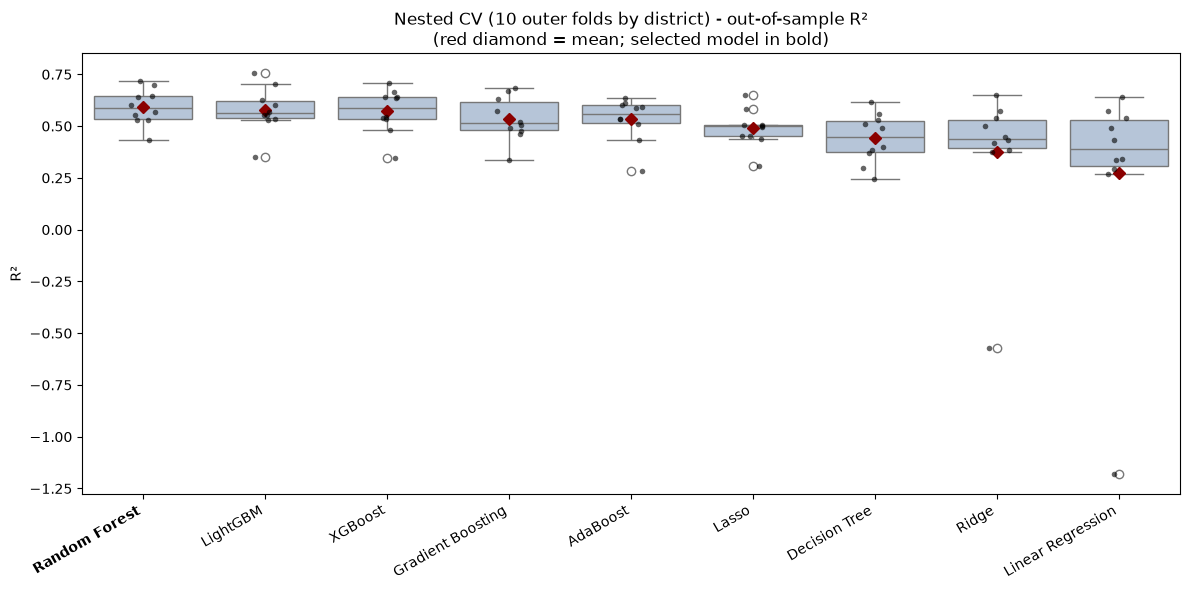

In [17]:
# =============================================================================
# BLOCK 5: BOX PLOT OF THE OUTER-FOLD R² BY MODEL
# =============================================================================
order = summary["model"].tolist()          # sorted by mean R²

boxplot_r2(df_folds, x="model", y="r2_outer", order=order, highlight=SELECTED_MODEL,
           title=f"Nested CV ({N_OUTER} outer folds by district) - out-of-sample R²\n"
                 f"(red diamond = mean; selected model in bold)",
           path=FOLDER / "boxplot_nested_cv.png")
plt.show()

In [18]:
# =============================================================================
# BLOCK 6: FINAL HYPERPARAMETERS (search on the FULL training set)
# =============================================================================
# The nested CV is used to COMPARE models. Now each model gets ONE search on the
# full training set to obtain its final hyperparameters.
# It is done for ALL models (not only the selected one) because they are also
# needed for the ensembles (averages / stacking).
final_models, final_params = fit_final_models(MODELS, X_train, y_train, groups_train, FOLDER,
                                              n_folds=N_INNER_FINAL, n_iter=N_ITER,
                                              n_jobs=N_JOBS, seed=SEED)

print(f"\nFinal hyperparameters of {SELECTED_MODEL}:")
for k, v in final_params[SELECTED_MODEL].items():
    print(f"   {k.replace('model__', '')}: {v}")

 Linear Regression: loaded
 Lasso: loaded
 Ridge: loaded
 Decision Tree: loaded


 Random Forest: loaded


 Gradient Boosting: loaded


 XGBoost: loaded
 LightGBM: loaded
 AdaBoost: loaded

Final hyperparameters of Random Forest:
   max_depth: 30
   max_features: sqrt
   max_samples: 0.5252496259847714
   min_samples_leaf: 18
   n_estimators: 487


,model,cv_r2_mean,cv_r2_std,cv_rmse_mean,test_r2,test_rmse,test_mae
0,Random Forest,0.5917,0.0866,5.6205,0.5490,6.0874,4.6839
1,LightGBM,0.5775,0.1086,5.7120,0.4557,6.6874,4.9989
2,XGBoost,0.5730,0.1069,5.7344,0.4799,6.5372,4.9459
3,Gradient Boosting,0.5350,0.1064,5.9915,0.4299,6.8443,5.0871
4,AdaBoost,0.5325,0.1058,6.0044,0.4767,6.5572,4.9842
5,Lasso,0.4890,0.0904,6.2708,0.5445,6.1178,4.8389
6,Decision Tree,0.4407,0.1196,6.5511,0.3119,7.5193,5.6338
7,Ridge,0.3747,0.3436,6.7045,0.5563,6.0380,4.7935
8,Linear Regression,0.2743,0.5258,7.0841,0.5516,6.0697,4.8175


Random Forest on the full test set: R² = 0.5490 | RMSE = 6.0874 | MAE = 4.6839


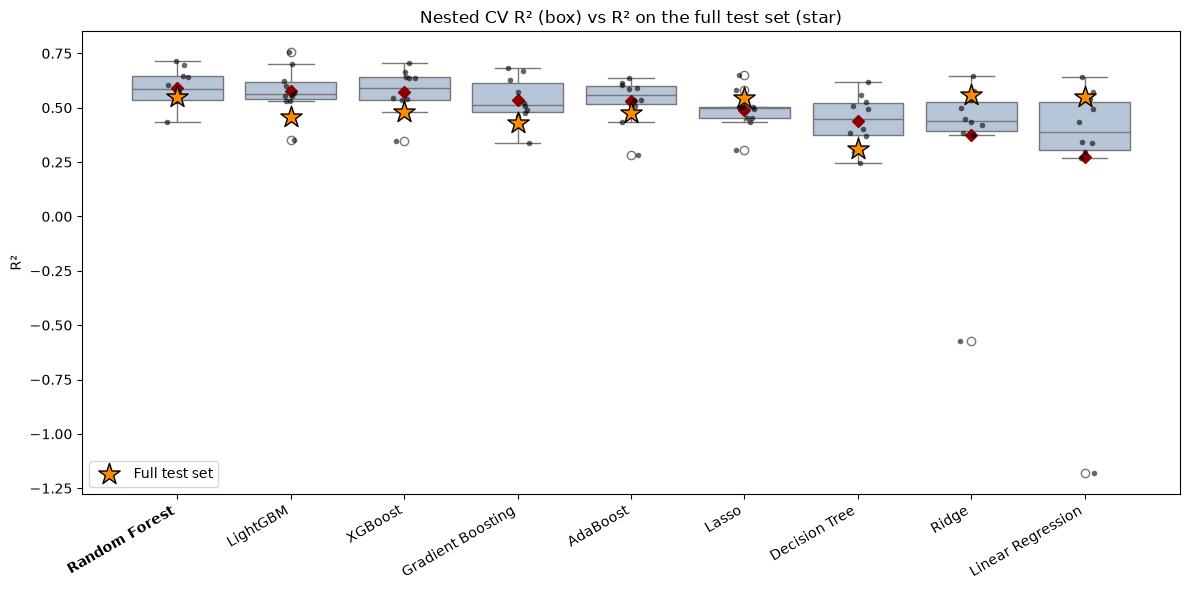

In [19]:
# =============================================================================
# BLOCK 7: EVALUATION ON THE FULL TEST SET (unseen districts)
# =============================================================================
# Every model is evaluated once on the whole test set (20% of the districts),
# which was never used for training or hyperparameter tuning.
test_base, preds_test_all = evaluate_on_test(final_models, X_test, y_test)

test_base = (summary[["model", "r2_mean", "r2_std", "rmse_mean"]]
             .rename(columns={"r2_mean": "cv_r2_mean", "r2_std": "cv_r2_std", "rmse_mean": "cv_rmse_mean"})
             .merge(test_base.rename(columns={"r2": "test_r2", "rmse": "test_rmse", "mae": "test_mae"}),
                    on="model")
             .sort_values("cv_r2_mean", ascending=False).reset_index(drop=True))
display(test_base.round(4))
test_base.to_csv(FOLDER / "test_base_models.csv", index=False)

sel = test_base.set_index("model").loc[SELECTED_MODEL]
print(f"{SELECTED_MODEL} on the full test set: R² = {sel.test_r2:.4f} | "
      f"RMSE = {sel.test_rmse:.4f} | MAE = {sel.test_mae:.4f}")

# Nested-CV box plot + full-test R² (orange star): if the star falls inside the box,
# the nested-CV estimate is confirmed on new districts.
boxplot_r2(df_folds, x="model", y="r2_outer", order=order, highlight=SELECTED_MODEL,
           test_r2=dict(zip(test_base["model"], test_base["test_r2"])),
           title="Nested CV R² (box) vs R² on the full test set (star)",
           path=FOLDER / "boxplot_nested_cv_vs_test.png")
plt.show()

## Ensembles

The three best models with different learning biases (Random Forest, XGBoost and Ridge) are combined with:
- **Simple average** of their predictions.
- **Weighted average**: non-negative weights that sum to 1, chosen to minimize the MSE of the out-of-fold predictions.
- **Stacking**: linear meta-model with non-negative coefficients fitted on the out-of-fold predictions.

In [20]:
BASE_MODELS   = ["XGBoost", "Ridge", "Random Forest"]
N_INNER_STACK = 5      # inner folds for the out-of-fold (OOF) predictions

FOLDER_ENS = FOLDER / "Ensembles"
FOLDER_ENS.mkdir(exist_ok=True)

In [21]:
# =============================================================================
# BLOCK 8: CV BY DISTRICT ON TRAIN (same 10 outer folds as the nested CV)
# =============================================================================
# All models (base and ensembles) are evaluated on the SAME folds with the SAME
# fixed hyperparameters -> fair comparison.
# Note: slightly optimistic because final_params were tuned on the full training set.
# The clean evaluation is the test set (Block 9).
df_cv_ens, weight_rows = ensemble_cv(BASE_MODELS, final_models, X_train, y_train, groups_train,
                                     FOLDER_ENS, n_outer=N_OUTER, n_folds=N_INNER_STACK,
                                     n_jobs=N_JOBS, seed=SEED)

summary_cv_ens = (df_cv_ens.groupby(["model", "type"])
                  .agg(r2_mean=("r2", "mean"), r2_std=("r2", "std"),
                       r2_min=("r2", "min"), r2_max=("r2", "max"),
                       rmse_mean=("rmse", "mean"), mae_mean=("mae", "mean"))
                  .reset_index())
summary_cv_ens["r2_se"] = summary_cv_ens["r2_std"] / np.sqrt(N_OUTER)

best_base_cv = summary_cv_ens.loc[summary_cv_ens["type"] == "Base", "r2_mean"].max()
summary_cv_ens["diff_vs_best_base"] = summary_cv_ens["r2_mean"] - best_base_cv

summary_cv_ens = summary_cv_ens.sort_values("r2_mean", ascending=False).reset_index(drop=True)
display(summary_cv_ens.round(4))

   fold  1/10: loaded
   fold  2/10: loaded
   fold  3/10: loaded
   fold  4/10: loaded
   fold  5/10: loaded
   fold  6/10: loaded
   fold  7/10: loaded
   fold  8/10: loaded
   fold  9/10: loaded
   fold 10/10: loaded


,model,type,r2_mean,r2_std,r2_min,r2_max,rmse_mean,mae_mean,r2_se,diff_vs_best_base
0,Stacking,Ensemble,0.6053,0.1002,0.4622,0.7602,5.5027,4.1781,0.0317,0.0235
1,Simple average,Ensemble,0.5896,0.0914,0.4606,0.7480,5.6138,4.3605,0.0289,0.0077
2,Weighted average,Ensemble,0.5863,0.0904,0.4661,0.7416,5.6462,4.4180,0.0286,0.0044
3,Random Forest,Base,0.5819,0.0798,0.4413,0.6975,5.6991,4.5158,0.0252,0.0000
4,XGBoost,Base,0.5731,0.0936,0.3824,0.7140,5.7560,4.4855,0.0296,-0.0088
5,Ridge,Base,0.3747,0.3436,-0.5714,0.6482,6.7045,5.2249,0.1087,-0.2072


In [22]:
# =============================================================================
# BLOCK 9: EVALUATION OF BASE MODELS AND ENSEMBLES ON THE FULL TEST SET
# =============================================================================
# Base models: those in final_models (already fitted on the full training set).
# Weights and meta-model: learned on OOF predictions over the full training set (folds by district).
path_test = FOLDER_ENS / "test_oof_pred.joblib"
if path_test.exists():
    oof_train, pred_test_base = joblib.load(path_test)
else:
    t0 = time.time()
    oof_train, pred_test_base = base_predictions(BASE_MODELS, final_models, X_train, y_train,
                                                 groups_train, X_test, seed=SEED,
                                                 n_folds=N_INNER_STACK, n_jobs=N_JOBS,
                                                 already_fitted=final_models)
    joblib.dump((oof_train, pred_test_base), path_test)
    print(f"Train OOF and test predictions ready in {(time.time() - t0) / 60:.1f} min")

w_final, meta_final = fit_ensembles(oof_train, y_train)
weight_rows.append(weights_row("Final (full train)", BASE_MODELS, w_final, meta_final))
preds_test = predict_all(pred_test_base, BASE_MODELS, w_final, meta_final)

# Final model: the best one in the CV on train (chosen without looking at the test set)
FINAL_MODEL = summary_cv_ens.iloc[0]["model"]

summary_test_ens = (pd.DataFrame([{"model": n, "type": "Base" if n in BASE_MODELS else "Ensemble",
                                   **regression_metrics(y_test, p)} for n, p in preds_test.items()])
                    .rename(columns={"r2": "test_r2", "rmse": "test_rmse", "mae": "test_mae"})
                    .merge(summary_cv_ens[["model", "r2_mean", "r2_std"]]
                           .rename(columns={"r2_mean": "cv_r2_mean", "r2_std": "cv_r2_std"}), on="model")
                    .sort_values("test_r2", ascending=False).reset_index(drop=True))
display(summary_test_ens.round(4))

df_weights = pd.DataFrame(weight_rows)
display(df_weights.round(4))

fin = summary_test_ens.set_index("model").loc[FINAL_MODEL]
print(f"FINAL MODEL: {FINAL_MODEL} -> test R² = {fin.test_r2:.4f} | "
      f"RMSE = {fin.test_rmse:.4f} | MAE = {fin.test_mae:.4f}")

,model,type,test_r2,test_rmse,test_mae,cv_r2_mean,cv_r2_std
0,Stacking,Ensemble,0.5670,5.9644,4.5043,0.6053,0.1002
1,Simple average,Ensemble,0.5620,5.9988,4.5634,0.5896,0.0914
2,Ridge,Base,0.5563,6.0380,4.7935,0.3747,0.3436
3,Weighted average,Ensemble,0.5560,6.0399,4.6046,0.5863,0.0904
4,Random Forest,Base,0.5490,6.0874,4.6839,0.5819,0.0798
5,XGBoost,Base,0.4799,6.5372,4.9459,0.5731,0.0936


,set,w_avg_XGBoost,w_avg_Ridge,w_avg_Random Forest,stack_intercept,stack_coef_XGBoost,stack_coef_Ridge,stack_coef_Random Forest
0,CV fold 1,0.2650,0.1742,0.5608,-3.2732,0.1593,0.1492,0.8956
1,CV fold 2,0.5109,0.1343,0.3549,-2.6373,0.4115,0.0885,0.6592
2,CV fold 3,0.2535,0.0024,0.7441,-3.1187,0.1712,0.0024,1.0376
3,CV fold 4,0.1009,0.1358,0.7633,-3.1014,0.0334,0.0972,1.0683
4,CV fold 5,0.3994,0.1796,0.4210,-3.4085,0.1682,0.0971,0.9814
5,CV fold 6,0.0717,0.3319,0.5964,-2.3973,0.0814,0.2899,0.7613
6,CV fold 7,0.1626,0.1402,0.6972,-2.8030,0.0944,0.0932,1.0017
7,CV fold 8,0.2234,0.1329,0.6437,-2.3947,0.1984,0.1019,0.8447
8,CV fold 9,0.4272,0.1257,0.4471,-2.7166,0.2474,0.0936,0.8336
9,CV fold 10,0.4498,0.1785,0.3717,-2.2018,0.3854,0.1573,0.5924


FINAL MODEL: Stacking -> test R² = 0.5670 | RMSE = 5.9644 | MAE = 4.5043


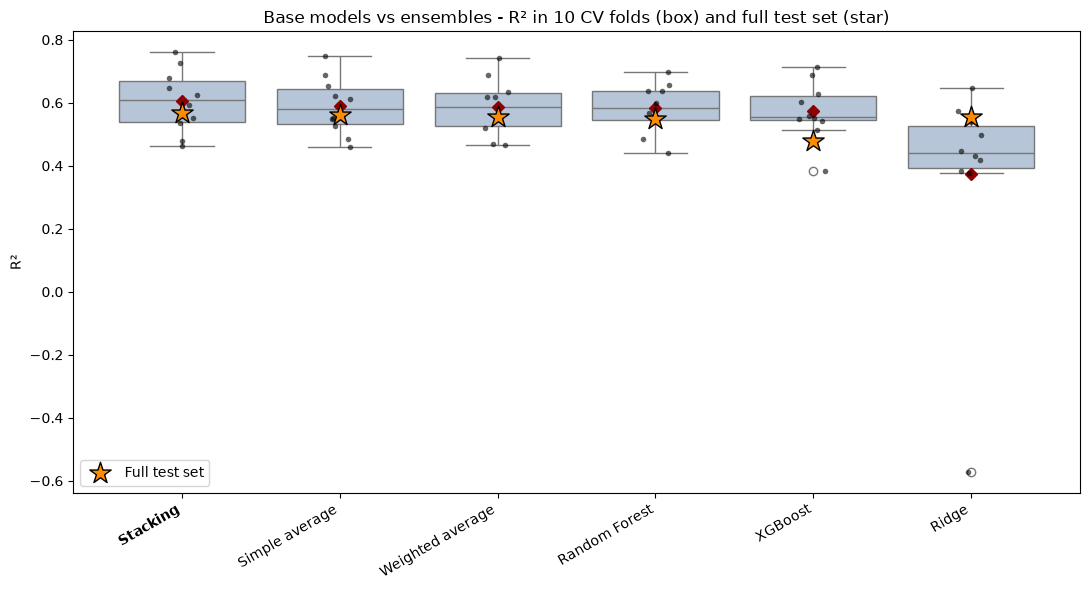

In [23]:
# =============================================================================
# BLOCK 10: BOX PLOT - CV on train (box) vs full test set (star), base models vs ensembles
# =============================================================================
order_ens = summary_cv_ens["model"].tolist()

boxplot_r2(df_cv_ens, x="model", y="r2", order=order_ens, highlight=FINAL_MODEL,
           test_r2=dict(zip(summary_test_ens["model"], summary_test_ens["test_r2"])),
           title=f"Base models vs ensembles - R² in {N_OUTER} CV folds (box) and full test set (star)",
           path=FOLDER_ENS / "boxplot_ensembles.png", figsize=(11, 6))
plt.show()

In [24]:
# =============================================================================
# BLOCK 11: EXCEL WITH THE PERFORMANCE
# =============================================================================
df_hyper = pd.DataFrame([{"model": n, "hyperparameter": k.replace("model__", ""), "value": str(v)}
                         for n in BASE_MODELS for k, v in final_params[n].items()])

df_pred_test = pd.DataFrame({"UBIGEO": groups_test.values, "y_true": y_test.values,
                             **{f"pred_{n}": p for n, p in preds_test.items()}})

sheets = {
    "Summary_NestedCV":  summary,
    "Test_Base_Models":  test_base,
    "Summary_CV_train":  summary_cv_ens,
    "Summary_Test":      summary_test_ens,
    "Folds_CV_train":    df_cv_ens,
    "Weights_Stacking":  df_weights,
    "Hyperparameters":   df_hyper,
    "Predictions_Test":  df_pred_test,
}

path_xlsx = FOLDER_ENS / "ensemble_performance.xlsx"
save_excel(sheets, path_xlsx)
print(f"Excel saved to: {path_xlsx}")

Excel saved to: ..\output\ModelNestedCV\Ensembles\ensemble_performance.xlsx


## Prediction for urban blocks without poverty data

In [25]:
# =============================================================================
# BLOCK 12: REFIT ON ALL LABELED BLOCKS AND PREDICT BLOCKS WITHOUT DATA
# =============================================================================
# Only after the evaluation. Fixed hyperparameters, no tuning.
# Train + test (all blocks with Pobreza2018) are used to learn from more districts.
print(f"Model used for prediction: {FINAL_MODEL}")

X_nodata = datasetTrNoData[X.columns]
g_all    = groups.reset_index(drop=True)
X_all    = X.reset_index(drop=True)
y_all    = y.reset_index(drop=True)

path_prod = FOLDER_ENS / "production_oof_pred.joblib"
if path_prod.exists():
    oof_all, pred_nodata_base = joblib.load(path_prod)
else:
    oof_all, pred_nodata_base = base_predictions(BASE_MODELS, final_models, X_all, y_all, g_all,
                                                 X_nodata, seed=SEED, n_folds=N_INNER_STACK,
                                                 n_jobs=N_JOBS)
    joblib.dump((oof_all, pred_nodata_base), path_prod)

w_prod, meta_prod = fit_ensembles(oof_all, y_all)
preds_nodata = predict_all(pred_nodata_base, BASE_MODELS, w_prod, meta_prod)

output = datasetTrNoData[["IDMANZANA", "UBIGEO"]].copy()
output["Pobreza2018_pred"] = preds_nodata[FINAL_MODEL]

# The poverty rate is a percentage: predictions outside [0, 100] are set to missing
out_of_range = ~output["Pobreza2018_pred"].between(0, 100)
output.loc[out_of_range, "Pobreza2018_pred"] = np.nan
print(f"Predictions outside [0, 100] set to missing: {out_of_range.sum():,} "
      f"of {len(output):,} ({out_of_range.mean():.2%})")

output["dpredict"] = 1
output.to_csv(FOLDER_ENS / f"predictions_{FINAL_MODEL.replace(' ', '_')}.csv", index=False)
output["Pobreza2018_pred"].describe()

Model used for prediction: Stacking


Predictions outside [0, 100] set to missing: 15,021 of 83,967 (17.89%)


count    68946.000000
mean        18.175078
std         12.408428
min          0.000442
25%          9.898432
50%         17.181812
75%         24.224330
max         99.976898
Name: Pobreza2018_pred, dtype: float64